In [27]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm


In [6]:
#2. load Data
df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [8]:
# 3. Data Preparation

df = df.drop(["instant", "dteday", "casual", "registered"], axis=1)


df['season'] = df['season'].map({1:'spring', 2:'summer', 3:'fall', 4:'winter'})
df['weathersit'] = df['weathersit'].map({1:'clear', 2:'mist', 3:'light_rain', 4:'heavy_rain'})


df = pd.get_dummies(df, drop_first=True)

In [10]:
# 4. Train - Test Split
X = df.drop("cnt", axis=1)
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [12]:
# 5. Build Linear Regression Model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Predictions
y_pred_train = lm.predict(X_train)
y_pred_test = lm.predict(X_test)

In [14]:
# 6. Model Evaluation

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

Train R2: 0.824899259586668
Test R2: 0.829137908716606


In [20]:
# 7. Statsmodels for Significance

X_train_sm = sm.add_constant(X_train)
X_train_sm = X_train_sm.astype(float)
y_train_sm = y_train.astype(float)

lr_model = sm.OLS(y_train_sm, X_train_sm).fit()
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     166.9
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.41e-177
Time:                        10:19:11   Log-Likelihood:                -4147.5
No. Observations:                 511   AIC:                             8325.
Df Residuals:                     496   BIC:                             8389.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  2241.31

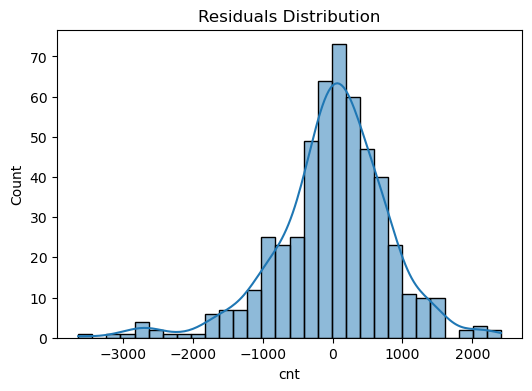

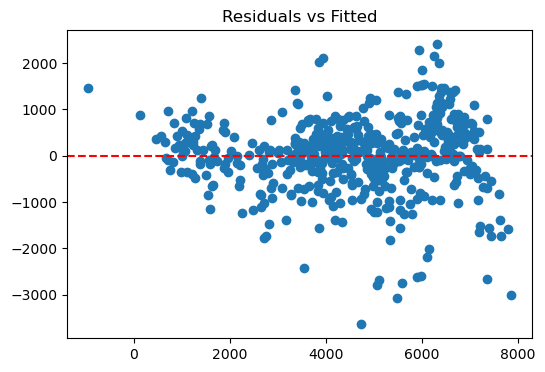

In [29]:
# 8. Residual Analysis

residuals = y_train - y_pred_train

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_train, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs Fitted")
plt.show()